# M1 — The victim model: DeiT-S on ImageNet-100

**What this notebook establishes.** A pretrained DeiT-S, adapted to a 100-class subset
of ImageNet *without any training*, and its clean accuracy. Everything in Part A is
measured against this baseline, so it has to be right before anything else happens.

**Why DeiT-S and not ViT-B.** RSA calls its model "ViT-small ... the DeiT-small model
(Touvron et al. 2020)". Matching it is what makes our Part A numbers directly
comparable to their Table 1 rather than approximately comparable.

**Why there is no training step.** RSA §4.3 adapts a 1000-way pretrained network by
slicing the classifier down to the 100 classes of interest and leaving every other
weight alone. That means **Act 1 needs only validation images**, never the 127k-image
training split — which is the single biggest reason the audit is affordable on a
laptop.

---

### Scale

`config.SCALE` controls everything. It ships as `DEV`: Imagenette, 10 real ImageNet
classes, a 98 MB download, runs in a minute. **DEV numbers are not results** — they
exist to prove the pipeline is correct. Switch to `config.FULL` in `fyp/config.py`
once ImageNet-100 is on disk.

In [1]:
# Make the `fyp` package importable whether you run this from notebooks/ or code/.
import sys, pathlib
_root = pathlib.Path.cwd()
for _ in range(3):
    if (_root / "fyp" / "__init__.py").exists():
        break
    _root = _root.parent
sys.path.insert(0, str(_root))

import torch
from fyp import config, data, models, hooks, metrics, attacks

config.seed_everything()
device = config.get_device()
print(config.describe())

model        : deit_small_patch16_224
scale        : full  (imagenet100, 512 eval images, batch 32, 100 attack steps)
device       : cuda
data root    : code\data
results root : code\results
gpu          : NVIDIA GeForce RTX 4050 Laptop GPU (5.3 GB free / 6.4 GB)
note         : Matches RSA's evaluation protocol. Needs the ImageNet-100 subset on disk.


## Step 1 — The dataset

A dataset here is always a directory of WordNet-id folders, so `ImageFolder` orders
targets by `sorted(wnids)`. We map those same wnids to their ImageNet-1k indices *in
the same order*. Target `t` from the loader then lines up with logit column `t`.

That ordering is the whole contract. Break it and every accuracy number silently
becomes noise, which is why `data.build_dataset` asserts it rather than trusting it.

In [2]:
ds, wnids, class_indices = data.build_dataset()
print(data.describe(ds, wnids, class_indices))

5000 images across 100 classes
  classes  : electric ray, cock, indigo bunting, bulbul, jay, chickadee, ... (+94 more)
  1k indices: [5, 7, 14, 16, 17, 19] ...


## Step 2 — The model

Two things happen inside `load_model` that are easy to get wrong and painful to debug:

1. **Head slicing** (`models.slice_head`) — RSA's exact recipe, no fine-tuning.
2. **`fused_attn` is switched off** (`models.disable_fused_attention`). timm ≥ 1.0
   routes attention through `F.scaled_dot_product_attention`, a fused kernel that
   **never materialises the attention matrix**. With it on, the attention weights and
   pre-softmax logits do not exist as tensors and no hook can capture them — M3, the
   mechanism study, Attention-Fool and `R_dom` would all silently read nothing.

Normalisation is folded *into* the model, not the transform, so the model eats images
in `[0,1]`. Attacks perturb natural pixel space; this is what makes `eps = 8/255` mean
the same thing on every channel.

In [3]:
clf, info = models.load_model(class_indices=class_indices)
for k, v in info.items():
    print(f"  {k:22s} {v}")

  model_name             deit_small_patch16_224
  mean                   (0.485, 0.456, 0.406)
  std                    (0.229, 0.224, 0.225)
  depth                  12
  num_heads              6
  head_dim               64
  scale                  0.125
  embed_dim              384
  num_classes            100
  n_params_m             21.7
  fused_attn_disabled    12
  device                 cuda


## Step 3 — Clean accuracy

RSA evaluates on **512 randomly sampled images**. `data.eval_subset` fixes the seed so
every method in the eventual comparison table sees the *same* images — which matters
far more than which images they are.

**Target on the real thing:** RSA reports **93.16%** clean for undefended ViT-small on
ImageNet-100. Landing near that is Gate A's first checkpoint. On DEV/Imagenette expect
~100% — ten well-separated classes is an easy problem and tells you only that the
plumbing works.

In [4]:
loader = data.make_loader(data.eval_subset(ds))

correct = total = 0
with torch.no_grad():
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        correct += (clf(x).argmax(1) == y).sum().item()
        total += y.numel()

print(f"clean accuracy: {100*correct/total:.2f}%  ({correct}/{total})")
print(f"RSA reports 93.16% for undefended ViT-small on ImageNet-100")

clean accuracy: 92.97%  (476/512)
RSA reports 93.16% for undefended ViT-small on ImageNet-100


## Step 4 — See the tokens

A ViT's unit of computation is the patch. The grid below is what the attack operates
on: **one** of these 196 cells, perturbed hard, takes an undefended DeiT-S from 93% to
**0%** in RSA's Table 1.

The red square is a 32 px patch. Note it straddles **9** tokens rather than 4, because
it is not grid-aligned — exactly the case RSA's window hyperparameter has to cover.

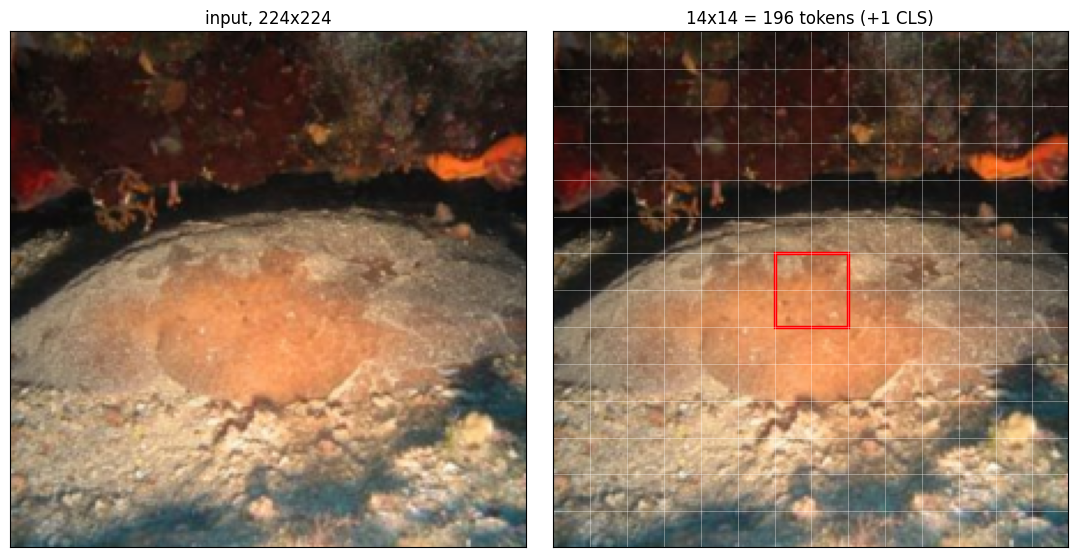

a 32px patch at (96,96) covers 4 tokens: [91, 92, 105, 106]
RSA would mask a 3x3 token window for this patch size


In [5]:
import matplotlib.pyplot as plt

x, y = next(iter(loader))
img = x[0].permute(1, 2, 0).numpy()

TOP, LEFT, SIZE = 96, 96, 32
tokens = metrics.patch_token_indices(TOP, LEFT, SIZE)

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
for a in ax:
    a.imshow(img)
    a.set_xticks([]); a.set_yticks([])
for i in range(1, config.GRID):
    ax[1].axhline(i * config.PATCH_SIZE, color="w", lw=0.4, alpha=0.6)
    ax[1].axvline(i * config.PATCH_SIZE, color="w", lw=0.4, alpha=0.6)
ax[1].add_patch(plt.Rectangle((LEFT, TOP), SIZE, SIZE, fill=False, ec="red", lw=2.5))
ax[0].set_title("input, 224x224")
ax[1].set_title(f"{config.GRID}x{config.GRID} = {config.N_IMAGE_TOKENS} tokens (+1 CLS)")
plt.tight_layout(); plt.show()

print(f"a {SIZE}px patch at ({TOP},{LEFT}) covers {len(tokens)} tokens: {tokens}")
print(f"RSA would mask a {metrics.rsa_window_size(SIZE)}x{metrics.rsa_window_size(SIZE)} token window for this patch size")

## Recap, and what M1 does *not* give you

Established: a DeiT-S sliced to the class subset, a fixed evaluation set, a clean
accuracy number, and the token geometry the attacks will target.

Not established: anything about robustness. And note the DEV caveat — Imagenette
accuracy says the pipeline works, nothing more.

**Next:** `M2_attacks.ipynb` breaks this model, and runs Athalye's warning-sign checks
on the attack harness itself.

## Record the run

Writes the headline numbers to `results/m1_baseline.json`. That file is tracked by git;
`results/figures/` is not.


In [6]:
# --- run record (fyp.results) ---
from fyp import results

results.save("m1_baseline", {
    "clean_acc_pct": 100 * correct / total,
    "correct": correct,
    "n_images": total,
    "rsa_reference_clean_acc_pct": 93.16,
    "n_classes": len(wnids),
    "model_info": info,
    "patch_demo": {
        "top": TOP, "left": LEFT, "size_px": SIZE,
        "n_tokens_covered": len(tokens),
        "rsa_window_tokens": metrics.rsa_window_size(SIZE),
    },
})


wrote code\results\m1_baseline.json  [RESULT]


WindowsPath('code/results/m1_baseline.json')